# Evaluación de MiniResNetV1 para Audio Event Detection en ESC-10

Notebook de Google Colab para evaluar el modelo `miniresnetv1_s1_64x50_tl.keras` del STM32 Model Zoo sobre ESC-10.

**Objetivo:** evaluar cuantitativamente un modelo preentrenado, sin reentrenamiento, y generar evidencias para el TFM.

El flujo implementado es:

1. Carga del modelo Keras.
2. Carga de ESC-50 desde Google Drive y filtrado del subconjunto ESC-10.
3. Preprocesado log-Mel compatible con entrada `(1, 64, 50, 1)`.
4. Inferencia por primer segundo o por clip completo mediante ventanas de 1 s.
5. Cálculo de accuracy, precision, recall, F1-score y matriz de confusión.
6. Exportación de una muestra preprocesada a `.h` con 3200 valores `float`.
7. Comparación posterior entre salida de Colab y salida de STM32.


## 1. Instalación e importación de librerías

In [ ]:
# Instalación opcional de dependencias si no están disponibles en el entorno de Colab.
# !pip install -q librosa soundfile scikit-learn

import json
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
import librosa
import librosa.display
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)

print("TensorFlow:", tf.__version__)
print("Num GPUs:", len(tf.config.list_physical_devices('GPU')))


TensorFlow: 2.20.0
Num GPUs: 1


## 2. Configuración general

In [ ]:
# =========================
# CONFIGURACIÓN PRINCIPAL
# =========================

# Carpeta raíz que contiene el modelo, los metadatos de ESC-50 y los archivos de audio.
PROJECT_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnetv1")

# Modelo Keras preentrenado MiniResNetV1.
MODEL_FILENAME = "miniresnetv1_s1_64x50_tl.keras"
MODEL_PATH = str(PROJECT_ROOT / MODEL_FILENAME)

# Archivo de metadatos de ESC-50.
ESC50_CSV_PATH = PROJECT_ROOT / "esc50.csv"

# Carpeta de audio de ESC-50.
AUDIO_ROOT = PROJECT_ROOT / "ESC-50-master/audio"

# Carpeta base de resultados.
WORK_DIR = Path("/content/miniresnet_esc10_eval")
RESULTS_DIR = WORK_DIR / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
EXPORT_DIR = RESULTS_DIR / "exported_inputs"

for d in [WORK_DIR, RESULTS_DIR, FIGURES_DIR, EXPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Dataset: modo local usando archivos ya subidos a Drive.
DATASET_MODE = "LOCAL_ESC50_CSV_AND_AUDIO"

# Evaluación sobre los cinco folds de ESC-50.
EVAL_FOLDS = [1, 2, 3, 4, 5]

# Estrategia de evaluación:
# "first_second": usa solo el primer segundo de cada clip.
# "full_clip_mean": divide el clip en ventanas de 1 s y promedia probabilidades.
EVAL_STRATEGY = "full_clip_mean"

# Parámetros de audio/preprocesado
SAMPLE_RATE = 16000
AUDIO_DURATION = 1.0
N_SAMPLES = int(SAMPLE_RATE * AUDIO_DURATION)

FRAME_SIZE = 1024
HOP_SIZE = 320
N_FFT = 1024
N_MELS = 64
TARGET_FRAMES = 50
TOP_DB = 80.0

# Rango de frecuencias Mel utilizado en el preprocesado.
FMIN = 0
FMAX = SAMPLE_RATE / 2

# Configuración de centrado de la STFT utilizada en la evaluación.
STFT_CENTER = True

# Referencia global para conversión a dB.
USE_GLOBAL_DB_REFERENCE = False
GLOBAL_POWER_REFERENCE = None  # se calculará más adelante si USE_GLOBAL_DB_REFERENCE=True

# Orden de las clases ESC-10 en la salida del modelo MiniResNetV1.
CLASS_NAMES = [
    "chainsaw",
    "clock_tick",
    "crackling_fire",
    "crying_baby",
    "dog",
    "helicopter",
    "rain",
    "rooster",
    "sea_waves",
    "sneezing",
]

CLASS_TO_INDEX = {name: idx for idx, name in enumerate(CLASS_NAMES)}
INDEX_TO_CLASS = {idx: name for idx, name in enumerate(CLASS_NAMES)}

display(pd.DataFrame({
    "model_index": list(INDEX_TO_CLASS.keys()),
    "class_name": list(INDEX_TO_CLASS.values())
}))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("MODEL_PATH:", MODEL_PATH)
print("ESC50_CSV_PATH:", ESC50_CSV_PATH)
print("AUDIO_ROOT:", AUDIO_ROOT)




,model_index,class_name
0,0,chainsaw
1,1,clock_tick
2,2,crackling_fire
3,3,crying_baby
4,4,dog
5,5,helicopter
6,6,rain
7,7,rooster
8,8,sea_waves
9,9,sneezing


PROJECT_ROOT: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnetv1
MODEL_PATH: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnetv1/miniresnetv1_s1_64x50_tl.keras
ESC50_CSV_PATH: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnetv1/esc50.csv
AUDIO_ROOT: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnetv1/ESC-50-master/audio


## 3. Montaje de Google Drive

In [ ]:
# Montaje de Google Drive cuando los archivos del proyecto están almacenados allí.
from google.colab import drive

MOUNT_DRIVE = True  # necesario si los archivos están en Google Drive

if MOUNT_DRIVE:
    drive.mount('/content/drive')


Mounted at /content/drive


## 4. Carga del modelo Keras

In [ ]:
model = tf.keras.models.load_model(MODEL_PATH, compile=False)

print("Model loaded from:", MODEL_PATH)
print("Input shape:", model.input_shape)
print("Output shape:", model.output_shape)
model.summary()

# Comprobaciones básicas.
expected_last_dims = (64, 50, 1)
actual_input_shape = tuple(model.input_shape[1:])

if actual_input_shape != expected_last_dims:
    print("\nWARNING: la forma de entrada no coincide exactamente con (64, 50, 1).")
    print("Forma esperada:", expected_last_dims)
    print("Forma real:", actual_input_shape)
else:
    print("\nOK: forma de entrada compatible con (1, 64, 50, 1).")

if CLASS_NAMES is not None and model.output_shape[-1] != len(CLASS_NAMES):
    print("\nWARNING: el número de salidas no coincide con el número de clases definido.")
    print("Salidas del modelo:", model.output_shape[-1])
    print("Clases definidas:", len(CLASS_NAMES))
else:
    print("\nNúmero de salidas del modelo:", model.output_shape[-1])


Model loaded from: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnetv1/miniresnetv1_s1_64x50_tl.keras
Input shape: (None, 64, 50, 1)
Output shape: (None, 10)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_1             │ (None, 64, 50, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 70, 56, 1) │          0 │ input_1[0][0]     │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 32, 25,    │      3,200 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 32, 25,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 32, 25,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 34, 27,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 16, 13,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 8, 7, 64)  │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 8, 7, 64)  │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 8, 7, 64)  │          0 │ conv2_block1_1_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 8, 7, 64)  │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 8, 7, 64)  │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 8, 7, 64)  │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 8, 7, 64)  │        256 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 8, 7, 64)  │          0 │ conv2_block1_2_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_add    │ (None, 8, 7, 64)  │          0 │ conv2_block1_0_b… │
│ (Add)               │                   │            │ conv2_block1_2_r… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 8, 7, 64)  │          0 │ conv2_block1_add

 Total params: 126,922 (495.79 KB)

 Trainable params: 35,850 (140.04 KB)

 Non-trainable params: 91,072 (355.75 KB)


OK: forma de entrada compatible con (1, 64, 50, 1).

Número de salidas del modelo: 10


## 5. Carga local de `esc50.csv` y filtrado ESC-10

In [ ]:
# En este modo no se descarga ESC-50.
# Se utiliza el archivo esc50.csv almacenado en Google Drive.

if not ESC50_CSV_PATH.exists():
    raise FileNotFoundError(
        f"No se encuentra esc50.csv en: {ESC50_CSV_PATH}\n"
        "Comprueba ESC50_CSV_PATH en la celda de configuración."
    )
meta_df = pd.read_csv(ESC50_CSV_PATH)
required_cols = {"filename", "target", "category", "fold", "esc10"}
missing_cols = required_cols - set(meta_df.columns)
if missing_cols:
    raise ValueError(f"Faltan columnas esperadas en esc50.csv: {missing_cols}")

# Máscara robusta para seleccionar solo ESC-10
esc10_mask = meta_df["esc10"].astype(str).str.lower().isin(["true", "1", "yes"])

# Localizar carpeta de audios.
# Si AUDIO_ROOT no existe, se intenta encontrar una carpeta con .wav dentro de PROJECT_ROOT.
if not AUDIO_ROOT.exists():
    print(f"AUDIO_ROOT no existe: {AUDIO_ROOT}")
    print("Buscando automáticamente archivos .wav dentro de PROJECT_ROOT...")

    wav_files = list(PROJECT_ROOT.rglob("*.wav"))
    if not wav_files:
        raise FileNotFoundError(
            "No se han encontrado archivos .wav dentro de PROJECT_ROOT. "
            "Comprueba la configuración de AUDIO_ROOT."
        )

    # Caso típico ESC-50: todos los wav están en una carpeta llamada audio.
    candidate_dirs = {}
    for wav in wav_files:
        candidate_dirs[wav.parent] = candidate_dirs.get(wav.parent, 0) + 1

    AUDIO_ROOT = max(candidate_dirs, key=candidate_dirs.get)
    print("AUDIO_ROOT detectado automáticamente:", AUDIO_ROOT)
    print("Nº .wav encontrados en esa carpeta:", candidate_dirs[AUDIO_ROOT])
else:
    print("AUDIO_ROOT exists:", AUDIO_ROOT)


AUDIO_ROOT exists: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnetv1/ESC-50-master/audio


In [ ]:
# Filtrado ESC-10.
# Nota: en algunos CSV la columna esc10 puede venir como booleano True/False,
# como string "True"/"False" o como 1/0. Esta conversión lo hace robusto.
esc10_df = meta_df[esc10_mask].copy()

eval_df = esc10_df[esc10_df["fold"].isin(EVAL_FOLDS)].copy()

# Mapear category -> índice interno del modelo.
missing_classes = sorted(set(eval_df["category"]) - set(CLASS_NAMES))
if missing_classes:
    raise ValueError(f"Hay clases ESC-10 no incluidas en CLASS_NAMES: {missing_classes}")

def resolve_audio_path(filename):
    """Resuelve la ruta de audio a partir del filename del CSV."""
    direct = AUDIO_ROOT / filename
    if direct.exists():
        return str(direct)

    # Búsqueda recursiva por si la carpeta tiene subdirectorios.
    matches = list(PROJECT_ROOT.rglob(filename))
    if matches:
        return str(matches[0])

    raise FileNotFoundError(
        f"No se encuentra el audio '{filename}'. "
        f"Probado en AUDIO_ROOT={AUDIO_ROOT} y búsqueda recursiva en PROJECT_ROOT={PROJECT_ROOT}."
    )

eval_df["filepath"] = eval_df["filename"].apply(resolve_audio_path)
eval_df["label_name"] = eval_df["category"]
eval_df["label_index"] = eval_df["label_name"].map(CLASS_TO_INDEX)

# Tabla final de evaluación
eval_df = eval_df[[
    "filename", "filepath", "fold", "target", "category", "label_name", "label_index"
]].reset_index(drop=True)

print("Número de audios ESC-10 filtrados:", len(esc10_df))
print("Número de audios en evaluación:", len(eval_df))
print("Folds usados:", EVAL_FOLDS)
print("Dataset mode:", DATASET_MODE)
display(eval_df.head())

# Distribución por clase en el conjunto de evaluación.
display(
    eval_df.groupby(["label_index", "label_name"])
    .size()
    .reset_index(name="n_samples")
    .sort_values("label_index")
)


Número de audios ESC-10 filtrados: 400
Número de audios en evaluación: 400
Folds usados: [1, 2, 3, 4, 5]
Dataset mode: LOCAL_ESC50_CSV_AND_AUDIO


,filename,filepath,fold,target,category,label_name,label_index
0,1-100032-A-0.wav,/content/drive/MyDrive/Colab Notebooks/TFM/Ver...,1,0,dog,dog,4
1,1-110389-A-0.wav,/content/drive/MyDrive/Colab Notebooks/TFM/Ver...,1,0,dog,dog,4
2,1-116765-A-41.wav,/content/drive/MyDrive/Colab Notebooks/TFM/Ver...,1,41,chainsaw,chainsaw,0
3,1-17150-A-12.wav,/content/drive/MyDrive/Colab Notebooks/TFM/Ver...,1,12,crackling_fire,crackling_fire,2
4,1-172649-A-40.wav,/content/drive/MyDrive/Colab Notebooks/TFM/Ver...,1,40,helicopter,helicopter,5


,label_index,label_name,n_samples
0,0,chainsaw,40
1,1,clock_tick,40
2,2,crackling_fire,40
3,3,crying_baby,40
4,4,dog,40
5,5,helicopter,40
6,6,rain,40
7,7,rooster,40
8,8,sea_waves,40
9,9,sneezing,40


## 6. Funciones de preprocesado

El modelo espera una entrada `float32` de forma `(1, 64, 50, 1)`.

Los principales parámetros que determinan la equivalencia del preprocesado entre
Colab y STM32 son:

- centrado de la STFT;
- ventana Hann;
- escala Mel;
- conversión de potencia a dB;
- referencia utilizada para la conversión a dB;
- orden de memoria del tensor;
- dimensiones finales de la entrada.

El preprocesado implementado en este notebook se utiliza posteriormente para
la validación mediante una entrada común exportada a STM32.


In [ ]:
def load_audio_mono(path, sample_rate=SAMPLE_RATE):
    """Carga audio mono remuestreado a sample_rate."""
    y, sr = librosa.load(path, sr=sample_rate, mono=True)
    return y.astype(np.float32), sr


def fix_audio_length(y, n_samples=N_SAMPLES):
    """Recorta o rellena con ceros hasta n_samples."""
    if len(y) < n_samples:
        y = np.pad(y, (0, n_samples - len(y)), mode="constant")
    else:
        y = y[:n_samples]
    return y.astype(np.float32)


def split_audio_into_windows(y, n_samples=N_SAMPLES, hop_samples=None):
    """Divide un clip en ventanas de 1 segundo.

    Por defecto usa ventanas no solapadas. Para solape, definir hop_samples.
    """
    if hop_samples is None:
        hop_samples = n_samples

    if len(y) < n_samples:
        return [fix_audio_length(y, n_samples)]

    windows = []
    for start in range(0, len(y) - n_samples + 1, hop_samples):
        windows.append(y[start:start+n_samples].astype(np.float32))

    if not windows:
        windows = [fix_audio_length(y, n_samples)]

    return windows


def compute_mel_power(y):
    """Calcula el espectrograma Mel de potencia utilizado en la evaluación."""
    mel_power = librosa.feature.melspectrogram(
        y=y,
        sr=SAMPLE_RATE,
        n_fft=N_FFT,
        hop_length=HOP_SIZE,
        win_length=FRAME_SIZE,
        window="hann",
        center=STFT_CENTER,
        power=2.0,
        n_mels=N_MELS,
        fmin=FMIN,
        fmax=FMAX,
        htk=False,
        norm="slaney",
    )
    return mel_power.astype(np.float32)


def power_to_db_global(mel_power, ref_power=None, top_db=TOP_DB):
    """Conversión potencia Mel -> dB.

    Si ref_power es None, usa referencia por muestra equivalente a ref=np.max.
    Si ref_power no es None, usa una referencia global fija.
    """
    if ref_power is None:
        logmel_db = librosa.power_to_db(
            mel_power,
            ref=np.max,
            top_db=top_db
        )
    else:
        logmel_db = librosa.power_to_db(
            mel_power,
            ref=float(ref_power),
            top_db=top_db
        )

    return logmel_db.astype(np.float32)


def pad_or_crop_time_frames(logmel, target_frames=TARGET_FRAMES):
    """Ajusta el eje temporal a TARGET_FRAMES."""
    n_mels, n_frames = logmel.shape

    if n_mels != N_MELS:
        raise ValueError(f"Número de bandas Mel incorrecto: {n_mels}, esperado {N_MELS}")

    if n_frames < target_frames:
        pad_width = target_frames - n_frames
        logmel = np.pad(logmel, ((0, 0), (0, pad_width)), mode="constant", constant_values=0.0)
    elif n_frames > target_frames:
        logmel = logmel[:, :target_frames]

    return logmel.astype(np.float32)


def preprocess_audio_array_to_logmel(y, global_power_reference=None, return_intermediate=False):
    """Preprocesa un array de audio mono de 1 segundo a tensor (1, 64, 50, 1)."""
    y = fix_audio_length(y, N_SAMPLES)
    mel_power = compute_mel_power(y)

    ref = global_power_reference if USE_GLOBAL_DB_REFERENCE else None
    logmel_db = power_to_db_global(mel_power, ref_power=ref, top_db=TOP_DB)

    real_frames = logmel_db.shape[1]
    logmel_fixed = pad_or_crop_time_frames(logmel_db, TARGET_FRAMES)

    tensor = logmel_fixed.astype(np.float32)[np.newaxis, :, :, np.newaxis]

    if return_intermediate:
        return tensor, {
            "audio": y,
            "mel_power": mel_power,
            "logmel_db_before_frame_fix": logmel_db,
            "real_frames": real_frames,
            "logmel_fixed": logmel_fixed,
        }

    return tensor


def preprocess_audio_to_logmel(path, global_power_reference=None, return_intermediate=False):
    y, sr = load_audio_mono(path, SAMPLE_RATE)
    y_1s = fix_audio_length(y, N_SAMPLES)
    return preprocess_audio_array_to_logmel(
        y_1s,
        global_power_reference=global_power_reference,
        return_intermediate=return_intermediate,
    )


# Comprobación del número de frames real con 1 s, n_fft=1024, hop=320 y center=True.
test_y = np.zeros(N_SAMPLES, dtype=np.float32)
test_mel = compute_mel_power(test_y)
print("Frames reales antes del padding/cropping:", test_mel.shape[1])
print("Forma Mel power:", test_mel.shape)
print("Forma final esperada:", (1, N_MELS, TARGET_FRAMES, 1))


Frames reales antes del padding/cropping: 51
Forma Mel power: (64, 51)
Forma final esperada: (1, 64, 50, 1)


## 7. Referencia global para conversión a dB

In [ ]:
def estimate_global_power_reference(filepaths, max_files=None):
    """Calcula una referencia global de potencia Mel como el máximo global del conjunto indicado."""
    max_power = 1e-12
    selected = filepaths[:max_files] if max_files is not None else filepaths

    for i, path in enumerate(selected):
        y, _ = load_audio_mono(path, SAMPLE_RATE)

        if EVAL_STRATEGY == "full_clip_mean":
            windows = split_audio_into_windows(y, N_SAMPLES)
        else:
            windows = [fix_audio_length(y, N_SAMPLES)]

        for w in windows:
            mel_power = compute_mel_power(w)
            max_power = max(max_power, float(np.max(mel_power)))

        if (i + 1) % 50 == 0:
            print(f"Processed {i+1}/{len(selected)} files. Current global ref: {max_power:.6e}")

    return float(max_power)


if USE_GLOBAL_DB_REFERENCE:
    GLOBAL_POWER_REFERENCE = estimate_global_power_reference(eval_df["filepath"].tolist())
else:
    GLOBAL_POWER_REFERENCE = None
    print("Using per-sample dB reference: ref=np.max for each Mel spectrogram.")

print("GLOBAL_POWER_REFERENCE:", GLOBAL_POWER_REFERENCE)


Using per-sample dB reference: ref=np.max for each Mel spectrogram.
GLOBAL_POWER_REFERENCE: None


## 8. Inferencia sobre una muestra individual

File: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnetv1/ESC-50-master/audio/1-100032-A-0.wav
True label: dog
Predicted: 6 rain confidence=1.0000
Top-3: [(6, 'rain', 0.9999605417251587), (5, 'helicopter', 3.818796540144831e-05), (0, 'chainsaw', 6.184376388773671e-07)]
Frames reales antes de ajustar a 50: 51


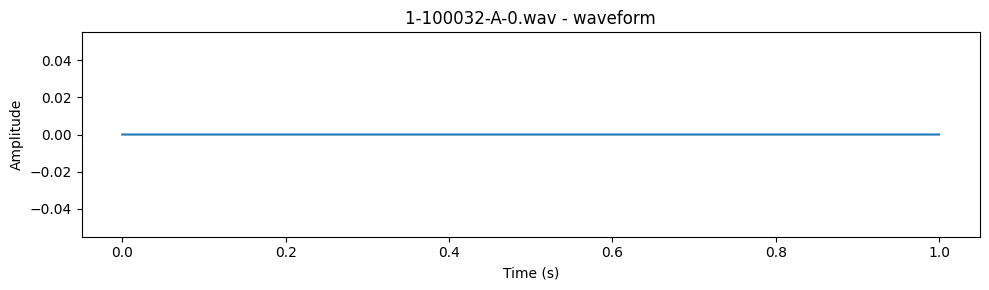

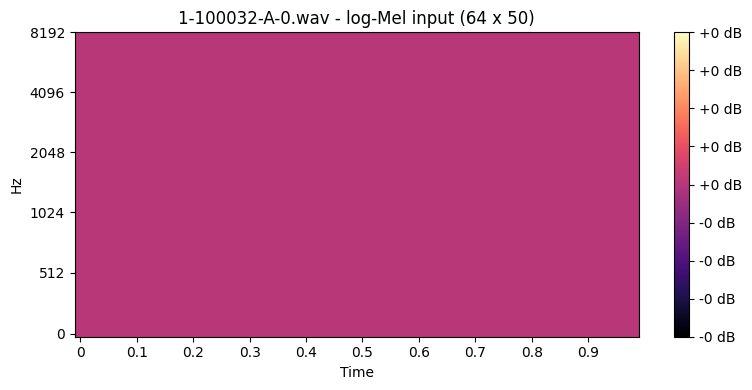

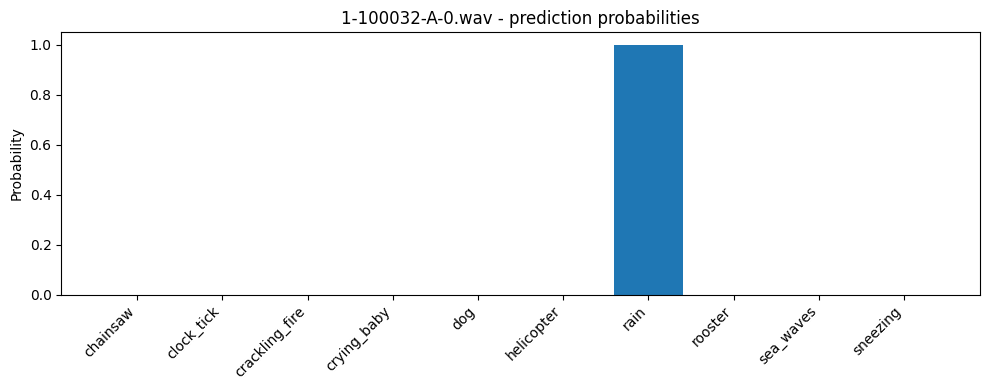

In [ ]:
def predict_tensor(logmel_tensor):
    """Ejecuta inferencia y devuelve vector 1D de salida."""
    output = model.predict(logmel_tensor, verbose=0)
    output = np.asarray(output).reshape(-1)
    return output.astype(np.float32)


def maybe_softmax(x):
    """Si la salida parece logits, aplica softmax. Si ya parece probabilidad, la deja igual."""
    x = np.asarray(x, dtype=np.float32)
    if np.all(x >= 0) and np.isclose(np.sum(x), 1.0, atol=1e-3):
        return x
    return tf.nn.softmax(x).numpy().astype(np.float32)


def top_k_predictions(prob, k=3):
    idxs = np.argsort(prob)[::-1][:k]
    return [(int(i), INDEX_TO_CLASS.get(int(i), str(i)), float(prob[i])) for i in idxs]


def predict_single_file(filepath, true_label=None, plot=True):
    logmel_tensor, info = preprocess_audio_to_logmel(
        filepath,
        global_power_reference=GLOBAL_POWER_REFERENCE,
        return_intermediate=True,
    )
    raw_output = predict_tensor(logmel_tensor)
    prob = maybe_softmax(raw_output)

    pred_idx = int(np.argmax(prob))
    pred_label = INDEX_TO_CLASS[pred_idx]

    result = {
        "filepath": filepath,
        "true_label": true_label,
        "predicted_index": pred_idx,
        "predicted_label": pred_label,
        "confidence": float(prob[pred_idx]),
        "top3": top_k_predictions(prob, 3),
        "raw_output": raw_output,
        "probabilities": prob,
        "real_frames_before_padding": info["real_frames"],
    }

    print("File:", filepath)
    print("True label:", true_label)
    print("Predicted:", pred_idx, pred_label, f"confidence={prob[pred_idx]:.4f}")
    print("Top-3:", result["top3"])
    print("Frames reales antes de ajustar a 50:", info["real_frames"])

    if plot:
        plot_waveform_and_logmel(info["audio"], info["logmel_fixed"], prob, title_prefix=Path(filepath).name)

    return result


def plot_waveform_and_logmel(audio, logmel_fixed, prob=None, title_prefix="Example"):
    # Waveform
    plt.figure(figsize=(10, 3))
    t = np.arange(len(audio)) / SAMPLE_RATE
    plt.plot(t, audio)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title(f"{title_prefix} - waveform")
    plt.tight_layout()
    plt.show()

    # Log-Mel
    plt.figure(figsize=(8, 4))
    librosa.display.specshow(
        logmel_fixed,
        sr=SAMPLE_RATE,
        hop_length=HOP_SIZE,
        x_axis="time",
        y_axis="mel",
        fmin=FMIN,
        fmax=FMAX,
    )
    plt.colorbar(format="%+2.0f dB")
    plt.title(f"{title_prefix} - log-Mel input (64 x 50)")
    plt.tight_layout()
    plt.show()

    # Probabilities
    if prob is not None:
        plt.figure(figsize=(10, 4))
        x = np.arange(len(CLASS_NAMES))
        plt.bar(x, prob)
        plt.xticks(x, CLASS_NAMES, rotation=45, ha="right")
        plt.ylabel("Probability")
        plt.title(f"{title_prefix} - prediction probabilities")
        plt.tight_layout()
        plt.show()


# Ejemplo rápido con la primera muestra del conjunto de evaluación.
example_row = eval_df.iloc[0]
single_result = predict_single_file(
    example_row["filepath"],
    true_label=example_row["label_name"],
    plot=True,
)


## 9. Evaluación del conjunto completo

In [ ]:
def predict_clip(filepath, strategy=EVAL_STRATEGY):
    """Predice un clip usando primer segundo o media de ventanas de 1 s."""
    y, _ = load_audio_mono(filepath, SAMPLE_RATE)

    if strategy == "first_second":
        windows = [fix_audio_length(y, N_SAMPLES)]
    elif strategy == "full_clip_mean":
        windows = split_audio_into_windows(y, N_SAMPLES, hop_samples=N_SAMPLES)
    else:
        raise ValueError(f"Estrategia no soportada: {strategy}")

    probs = []

    for w in windows:
        tensor = preprocess_audio_array_to_logmel(
            w,
            global_power_reference=GLOBAL_POWER_REFERENCE,
            return_intermediate=False,
        )
        raw = predict_tensor(tensor)
        prob = maybe_softmax(raw)
        probs.append(prob)

    clip_prob = np.mean(np.stack(probs, axis=0), axis=0)
    pred_idx = int(np.argmax(clip_prob))

    return {
        "predicted_index": pred_idx,
        "predicted_label": INDEX_TO_CLASS[pred_idx],
        "confidence": float(clip_prob[pred_idx]),
        "probabilities": clip_prob.astype(np.float32),
        "n_windows": len(windows),
    }


def evaluate_dataset(df, strategy=EVAL_STRATEGY):
    records = []
    y_true = []
    y_pred = []
    y_prob = []

    for i, row in df.iterrows():
        pred = predict_clip(row["filepath"], strategy=strategy)

        y_true.append(int(row["label_index"]))
        y_pred.append(int(pred["predicted_index"]))
        y_prob.append(pred["probabilities"])

        records.append({
            "filename": row["filename"],
            "filepath": row["filepath"],
            "fold": int(row["fold"]),
            "true_index": int(row["label_index"]),
            "true_label": row["label_name"],
            "predicted_index": int(pred["predicted_index"]),
            "predicted_label": pred["predicted_label"],
            "confidence": float(pred["confidence"]),
            "n_windows": int(pred["n_windows"]),
            "correct": int(row["label_index"]) == int(pred["predicted_index"]),
            "top3_predictions": json.dumps(top_k_predictions(pred["probabilities"], 3), ensure_ascii=False),
        })

        if (i + 1) % 20 == 0:
            print(f"Evaluated {i+1}/{len(df)} files")

    predictions_df = pd.DataFrame(records)
    y_true = np.array(y_true, dtype=np.int64)
    y_pred = np.array(y_pred, dtype=np.int64)
    y_prob = np.stack(y_prob, axis=0).astype(np.float32)

    return y_true, y_pred, y_prob, predictions_df


y_true, y_pred, y_prob, predictions_df = evaluate_dataset(eval_df, strategy=EVAL_STRATEGY)

accuracy = accuracy_score(y_true, y_pred)
print("Evaluation strategy:", EVAL_STRATEGY)
print("Accuracy:", accuracy)

display(predictions_df.head())


Evaluated 20/400 files
Evaluated 40/400 files
Evaluated 60/400 files
Evaluated 80/400 files
Evaluated 100/400 files
Evaluated 120/400 files
Evaluated 140/400 files
Evaluated 160/400 files
Evaluated 180/400 files
Evaluated 200/400 files
Evaluated 220/400 files
Evaluated 240/400 files
Evaluated 260/400 files
Evaluated 280/400 files
Evaluated 300/400 files
Evaluated 320/400 files
Evaluated 340/400 files
Evaluated 360/400 files
Evaluated 380/400 files
Evaluated 400/400 files
Evaluation strategy: full_clip_mean
Accuracy: 0.8425


,filename,filepath,fold,true_index,true_label,predicted_index,predicted_label,confidence,n_windows,correct,top3_predictions
0,1-100032-A-0.wav,/content/drive/MyDrive/Colab Notebooks/TFM/Ver...,1,4,dog,6,rain,0.799968,5,False,"[[6, ""rain"", 0.799968421459198], [9, ""sneezing..."
1,1-110389-A-0.wav,/content/drive/MyDrive/Colab Notebooks/TFM/Ver...,1,4,dog,6,rain,0.799968,5,False,"[[6, ""rain"", 0.799968421459198], [4, ""dog"", 0...."
2,1-116765-A-41.wav,/content/drive/MyDrive/Colab Notebooks/TFM/Ver...,1,0,chainsaw,0,chainsaw,0.882191,5,True,"[[0, ""chainsaw"", 0.8821908235549927], [8, ""sea..."
3,1-17150-A-12.wav,/content/drive/MyDrive/Colab Notebooks/TFM/Ver...,1,2,crackling_fire,2,crackling_fire,0.987047,5,True,"[[2, ""crackling_fire"", 0.9870468974113464], [6..."
4,1-172649-A-40.wav,/content/drive/MyDrive/Colab Notebooks/TFM/Ver...,1,5,helicopter,5,helicopter,0.966163,5,True,"[[5, ""helicopter"", 0.9661626815795898], [0, ""c..."


## 10. Métricas globales y por clase

In [ ]:
labels = list(range(len(CLASS_NAMES)))

report_dict = classification_report(
    y_true,
    y_pred,
    labels=labels,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)

report_text = classification_report(
    y_true,
    y_pred,
    labels=labels,
    target_names=CLASS_NAMES,
    zero_division=0,
)

print(report_text)

precision, recall, f1, support = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=labels,
    zero_division=0,
)

metrics_df = pd.DataFrame({
    "class_index": labels,
    "class_name": CLASS_NAMES,
    "precision": precision,
    "recall": recall,
    "f1_score": f1,
    "support": support,
})

macro_f1 = report_dict["macro avg"]["f1-score"]
weighted_f1 = report_dict["weighted avg"]["f1-score"]

summary_df = pd.DataFrame({
    "Métrica": [
        "Accuracy global",
        "Macro F1-score",
        "Weighted F1-score",
        "Nº clases",
        "Nº muestras evaluadas",
        "Tipo de evaluación",
        "Modelo",
        "Entrada",
        "Dataset",
    ],
    "Valor": [
        f"{accuracy:.4f}",
        f"{macro_f1:.4f}",
        f"{weighted_f1:.4f}",
        len(CLASS_NAMES),
        len(y_true),
        EVAL_STRATEGY,
        "MiniResNetV1",
        "64 x 50 x 1 log-Mel",
        "ESC-10 filtered from ESC-50",
    ]
})

display(summary_df)
display(metrics_df)


                precision    recall  f1-score   support

      chainsaw       0.95      0.95      0.95        40
    clock_tick       0.92      0.90      0.91        40
crackling_fire       0.95      0.88      0.91        40
   crying_baby       0.93      0.95      0.94        40
           dog       0.97      0.75      0.85        40
    helicopter       0.95      0.95      0.95        40
          rain       0.46      1.00      0.63        40
       rooster       1.00      0.65      0.79        40
     sea_waves       1.00      0.97      0.99        40
      sneezing       0.85      0.42      0.57        40

      accuracy                           0.84       400
     macro avg       0.90      0.84      0.85       400
  weighted avg       0.90      0.84      0.85       400



,Métrica,Valor
0,Accuracy global,0.8425
1,Macro F1-score,0.8476
2,Weighted F1-score,0.8476
3,Nº clases,10
4,Nº muestras evaluadas,400
5,Tipo de evaluación,full_clip_mean
6,Modelo,MiniResNetV1
7,Entrada,64 x 50 x 1 log-Mel
8,Dataset,ESC-10 filtered from ESC-50


,class_index,class_name,precision,recall,f1_score,support
0,0,chainsaw,0.950000,0.950,0.950000,40
1,1,clock_tick,0.923077,0.900,0.911392,40
2,2,crackling_fire,0.945946,0.875,0.909091,40
3,3,crying_baby,0.926829,0.950,0.938272,40
4,4,dog,0.967742,0.750,0.845070,40
5,5,helicopter,0.950000,0.950,0.950000,40
6,6,rain,0.459770,1.000,0.629921,40
7,7,rooster,1.000000,0.650,0.787879,40
8,8,sea_waves,1.000000,0.975,0.987342,40
9,9,sneezing,0.850000,0.425,0.566667,40


## 11. Matriz de confusión

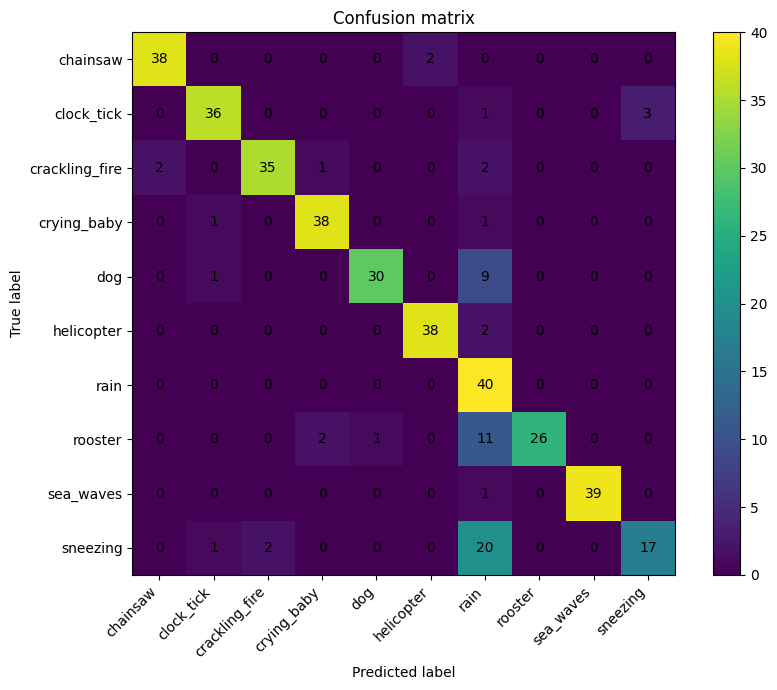

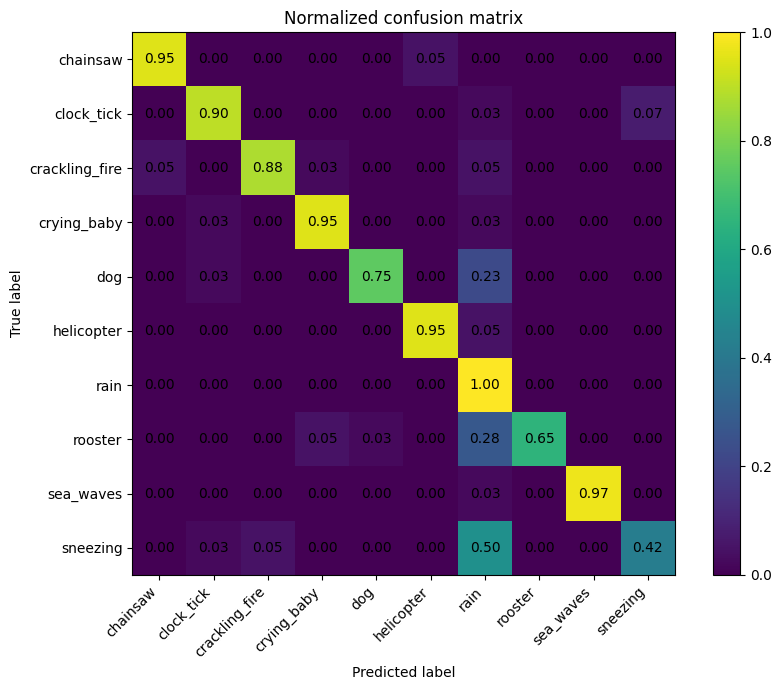

In [ ]:
cm = confusion_matrix(y_true, y_pred, labels=labels)

def plot_confusion_matrix(cm, class_names, normalize=False, save_path=None):
    if normalize:
        row_sums = cm.sum(axis=1, keepdims=True)
        cm_plot = np.divide(cm, row_sums, where=row_sums != 0)
        title = "Normalized confusion matrix"
        fmt = ".2f"
    else:
        cm_plot = cm
        title = "Confusion matrix"
        fmt = "d"

    plt.figure(figsize=(9, 7))
    im = plt.imshow(cm_plot, interpolation="nearest")
    plt.title(title)
    plt.colorbar(im)
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45, ha="right")
    plt.yticks(tick_marks, class_names)

    thresh = cm_plot.max() / 2.0 if cm_plot.max() > 0 else 0
    for i in range(cm_plot.shape[0]):
        for j in range(cm_plot.shape[1]):
            value = format(cm_plot[i, j], fmt)
            plt.text(j, i, value, ha="center", va="center")

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


plot_confusion_matrix(cm, CLASS_NAMES, normalize=False, save_path=FIGURES_DIR / "confusion_matrix.png")
plot_confusion_matrix(cm, CLASS_NAMES, normalize=True, save_path=FIGURES_DIR / "confusion_matrix_normalized.png")


## 12. Gráficas de métricas por clase

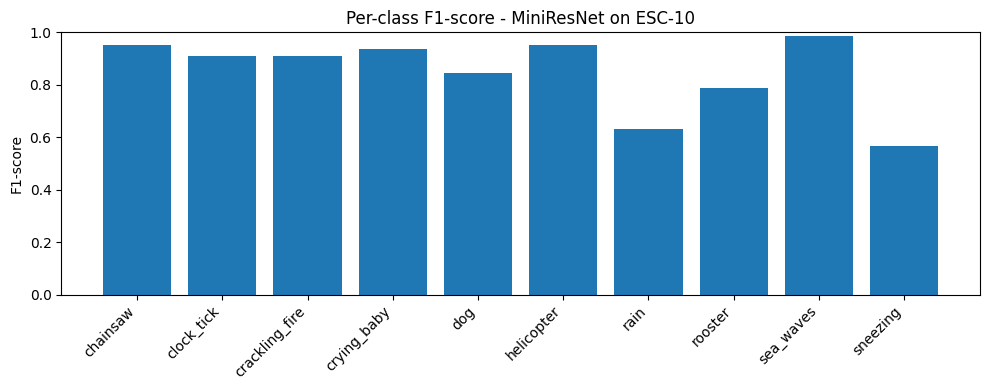

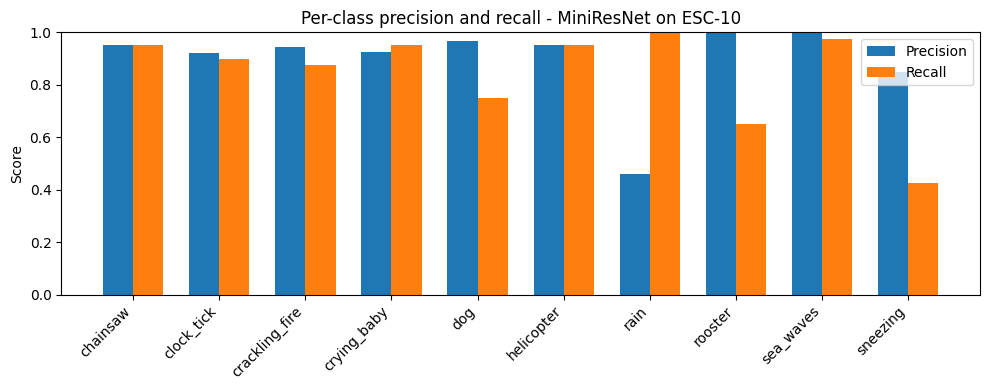

In [ ]:
def plot_class_f1(metrics_df, save_path=None):
    plt.figure(figsize=(10, 4))
    x = np.arange(len(metrics_df))
    plt.bar(x, metrics_df["f1_score"])
    plt.xticks(x, metrics_df["class_name"], rotation=45, ha="right")
    plt.ylim(0, 1.0)
    plt.ylabel("F1-score")
    plt.title("Per-class F1-score - MiniResNet on ESC-10")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def plot_precision_recall(metrics_df, save_path=None):
    x = np.arange(len(metrics_df))
    width = 0.35

    plt.figure(figsize=(10, 4))
    plt.bar(x - width/2, metrics_df["precision"], width, label="Precision")
    plt.bar(x + width/2, metrics_df["recall"], width, label="Recall")
    plt.xticks(x, metrics_df["class_name"], rotation=45, ha="right")
    plt.ylim(0, 1.0)
    plt.ylabel("Score")
    plt.title("Per-class precision and recall - MiniResNet on ESC-10")
    plt.legend()
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


plot_class_f1(metrics_df, save_path=FIGURES_DIR / "class_f1_scores.png")
plot_precision_recall(metrics_df, save_path=FIGURES_DIR / "class_precision_recall.png")


## 13. Ejemplos de predicciones correctas e incorrectas

In [ ]:
correct_examples_df = predictions_df[predictions_df["correct"] == True].copy()
incorrect_examples_df = predictions_df[predictions_df["correct"] == False].copy()

# Ordenar: correctas por menor confianza para ejemplos interesantes; incorrectas por mayor confianza.
correct_examples_df = correct_examples_df.sort_values("confidence", ascending=True).head(5)
incorrect_examples_df = incorrect_examples_df.sort_values("confidence", ascending=False).head(5)

print("Correct examples:")
display(correct_examples_df[[
    "filename", "true_label", "predicted_label", "confidence", "n_windows", "top3_predictions"
]])

print("Incorrect examples:")
display(incorrect_examples_df[[
    "filename", "true_label", "predicted_label", "confidence", "n_windows", "top3_predictions"
]])


Correct examples:


,filename,true_label,predicted_label,confidence,n_windows,top3_predictions
28,1-22694-B-20.wav,crying_baby,crying_baby,0.303038,5,"[[3, ""crying_baby"", 0.3030382990837097], [2, ""..."
149,2-81270-A-1.wav,rooster,rooster,0.346093,5,"[[7, ""rooster"", 0.34609341621398926], [4, ""dog..."
356,5-200339-A-1.wav,rooster,rooster,0.364603,5,"[[7, ""rooster"", 0.3646028935909271], [4, ""dog""..."
354,5-200334-A-1.wav,rooster,rooster,0.366253,5,"[[7, ""rooster"", 0.3662528693675995], [6, ""rain..."
142,2-71162-A-1.wav,rooster,rooster,0.371604,5,"[[7, ""rooster"", 0.3716040253639221], [3, ""cryi..."


Incorrect examples:


,filename,true_label,predicted_label,confidence,n_windows,top3_predictions
0,1-100032-A-0.wav,dog,rain,0.799968,5,"[[6, ""rain"", 0.799968421459198], [9, ""sneezing..."
1,1-110389-A-0.wav,dog,rain,0.799968,5,"[[6, ""rain"", 0.799968421459198], [4, ""dog"", 0...."
39,1-31748-A-21.wav,sneezing,rain,0.799968,5,"[[6, ""rain"", 0.799968421459198], [9, ""sneezing..."
246,4-157611-A-41.wav,chainsaw,helicopter,0.796123,5,"[[5, ""helicopter"", 0.796122670173645], [0, ""ch..."
222,3-163459-A-0.wav,dog,rain,0.790983,5,"[[6, ""rain"", 0.7909829020500183], [4, ""dog"", 0..."


File: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnetv1/ESC-50-master/audio/1-100032-A-0.wav
True label: dog
Predicted: 6 rain confidence=1.0000
Top-3: [(6, 'rain', 0.9999605417251587), (5, 'helicopter', 3.818796540144831e-05), (0, 'chainsaw', 6.184376388773671e-07)]
Frames reales antes de ajustar a 50: 51


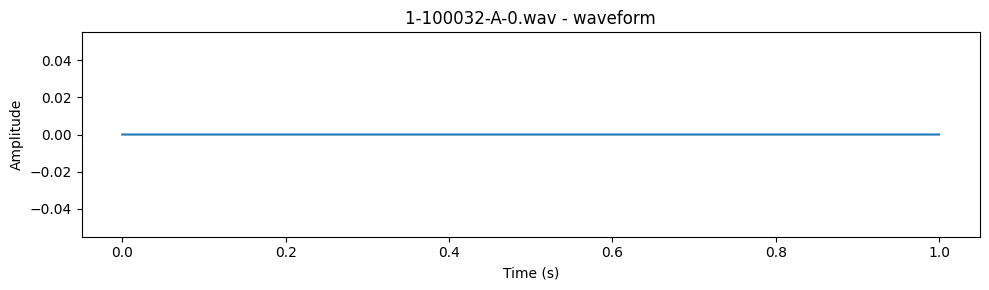

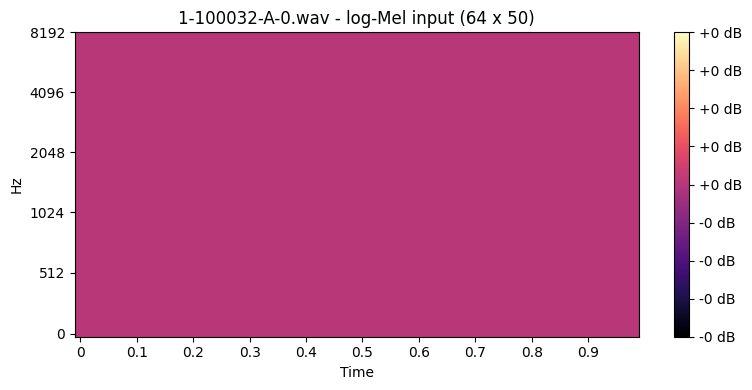

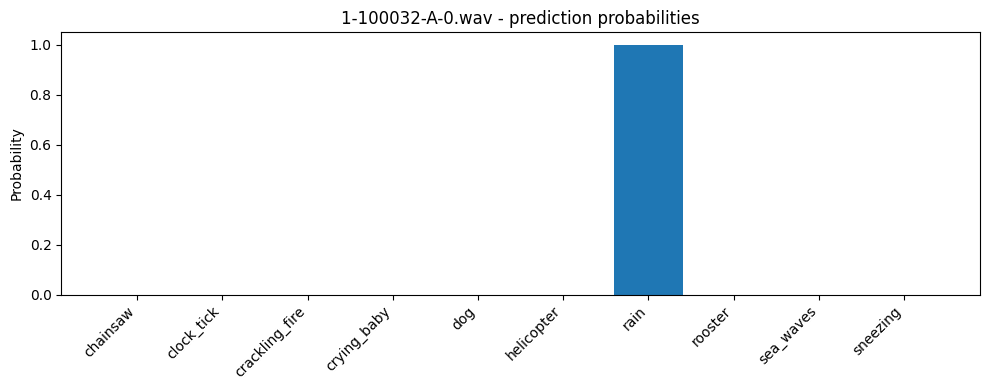

In [ ]:
# Visualizar un ejemplo incorrecto si existe; si no, uno correcto.
if len(incorrect_examples_df) > 0:
    example_to_plot = incorrect_examples_df.iloc[0]
else:
    example_to_plot = correct_examples_df.iloc[0]

_ = predict_single_file(
    example_to_plot["filepath"],
    true_label=example_to_plot["true_label"],
    plot=True,
)


## 14. Exportación de una muestra preprocesada a archivo `.h`

In [ ]:
def export_logmel_to_c_header(logmel_tensor, output_path, array_name="test_input"):
    """Exporta tensor (1,64,50,1) como array C float de 3200 valores."""
    output_path = Path(output_path)

    arr = np.asarray(logmel_tensor, dtype=np.float32)
    if arr.shape != (1, N_MELS, TARGET_FRAMES, 1):
        raise ValueError(f"Forma incorrecta: {arr.shape}, esperada {(1, N_MELS, TARGET_FRAMES, 1)}")

    flat = arr.reshape(-1).astype(np.float32)
    if len(flat) != N_MELS * TARGET_FRAMES:
        raise ValueError(f"Tamaño incorrecto: {len(flat)}, esperado {N_MELS * TARGET_FRAMES}")

    guard = output_path.name.replace(".", "_").replace("-", "_").upper()

    lines = []
    lines.append(f"#ifndef {guard}")
    lines.append(f"#define {guard}")
    lines.append("")
    lines.append(f"#define {array_name.upper()}_SIZE {len(flat)}")
    lines.append("")
    lines.append(f"const float {array_name}[{array_name.upper()}_SIZE] = {{")

    for i in range(0, len(flat), 8):
        chunk = flat[i:i+8]
        values = ", ".join([f"{float(v):.8e}f" for v in chunk])
        lines.append("    " + values + ",")

    lines.append("};")
    lines.append("")
    lines.append(f"#endif /* {guard} */")
    lines.append("")

    output_path.write_text("\n".join(lines))
    return output_path, flat


# Seleccionar muestra a exportar.
EXPORT_SAMPLE_INDEX = 0
export_row = eval_df.iloc[EXPORT_SAMPLE_INDEX]

export_tensor, export_info = preprocess_audio_to_logmel(
    export_row["filepath"],
    global_power_reference=GLOBAL_POWER_REFERENCE,
    return_intermediate=True,
)

header_path = EXPORT_DIR / "test_input.h"
npy_path = EXPORT_DIR / "test_input.npy"

header_path, flat = export_logmel_to_c_header(export_tensor, header_path, array_name="test_input")
np.save(npy_path, export_tensor)

print("Exported header:", header_path)
print("Exported npy:", npy_path)
print("Header values:", len(flat))
print("Tensor shape:", export_tensor.shape)
print("Tensor dtype:", export_tensor.dtype)
print("Real frames before padding:", export_info["real_frames"])

# Predicción Colab para la muestra exportada.
export_raw = predict_tensor(export_tensor)
export_prob = maybe_softmax(export_raw)
export_pred_idx = int(np.argmax(export_prob))

print("\nColab prediction for exported sample:")
print("File:", export_row["filename"])
print("True label:", export_row["label_name"])
print("Predicted:", export_pred_idx, INDEX_TO_CLASS[export_pred_idx])
print("Top-3:", top_k_predictions(export_prob, 3))


Exported header: /content/miniresnet_esc10_eval/results/exported_inputs/test_input.h
Exported npy: /content/miniresnet_esc10_eval/results/exported_inputs/test_input.npy
Header values: 3200
Tensor shape: (1, 64, 50, 1)
Tensor dtype: float32
Real frames before padding: 51

Colab prediction for exported sample:
File: 1-100032-A-0.wav
True label: dog
Predicted: 6 rain
Top-3: [(6, 'rain', 0.9999605417251587), (5, 'helicopter', 3.818796540144831e-05), (0, 'chainsaw', 6.184376388773671e-07)]


## 15. Comparación Colab vs STM32

Colab prediction: 6 rain
STM32 prediction: 6 rain
Max absolute error, raw: 1.1920928955078125e-07
Mean absolute error, raw: 1.3887356153929886e-08
Max absolute error, prob: 1.1920928955078125e-07
Mean absolute error, prob: 1.3887356153929886e-08


,class_index,class_name,colab_raw,stm32_raw,abs_error_raw,colab_prob,stm32_prob,abs_error_prob
0,0,chainsaw,6.184376e-07,6.200000e-07,1.562341e-09,6.184376e-07,6.200000e-07,1.562341e-09
1,1,clock_tick,3.882686e-09,0.000000e+00,3.882686e-09,3.882686e-09,0.000000e+00,3.882686e-09
2,2,crackling_fire,4.314684e-10,0.000000e+00,4.314684e-10,4.314684e-10,0.000000e+00,4.314684e-10
3,3,crying_baby,1.154399e-08,1.000000e-08,1.543990e-09,1.154399e-08,1.000000e-08,1.543990e-09
4,4,dog,1.383696e-09,0.000000e+00,1.383696e-09,1.383696e-09,0.000000e+00,1.383696e-09
5,5,helicopter,3.818797e-05,3.819000e-05,2.033630e-09,3.818797e-05,3.819000e-05,2.033630e-09
6,6,rain,9.999605e-01,9.999607e-01,1.192093e-07,9.999605e-01,9.999607e-01,1.192093e-07
7,7,rooster,2.799945e-09,0.000000e+00,2.799945e-09,2.799945e-09,0.000000e+00,2.799945e-09
8,8,sea_waves,4.351754e-07,4.400000e-07,4.824585e-09,4.351754e-07,4.400000e-07,4.824585e-09
9,9,sneezing,7.120193e-08,7.000000e-08,1.201933e-09,7.120193e-08,7.000000e-08,1.201933e-09


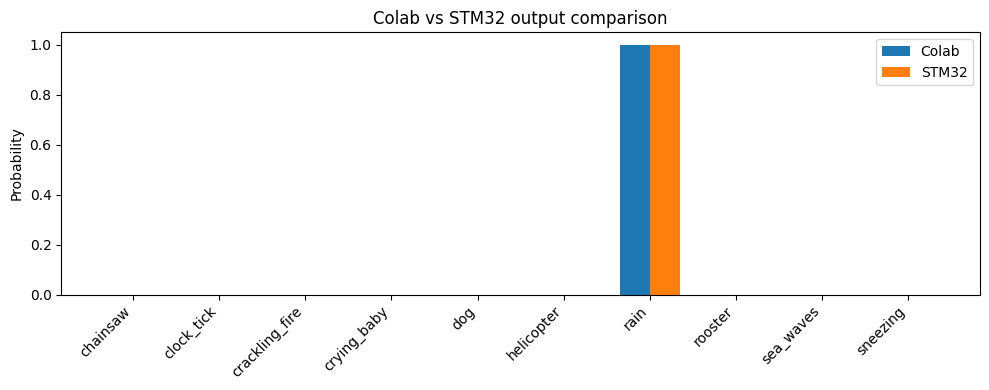

In [ ]:
# Salida obtenida en STM32 utilizando la misma entrada test_input.h.
# Debe contener 10 valores, en el mismo orden de clases que CLASS_NAMES.
# Si STM32 devuelve logits en lugar de probabilidades, el notebook aplicará softmax
# solo para comparación de probabilidades, pero también conserva los valores brutos.

stm32_output = np.array([
    0.00000062, 0.00000000, 0.00000000, 0.00000001, 0.00000000, 0.00003819, 0.99996066, 0.00000000, 0.00000044, 0.00000007


], dtype=np.float32)

def compare_colab_stm32(colab_raw_output, stm32_output):
    if stm32_output.size != len(CLASS_NAMES):
        print("STM32 output todavía no introducida o tamaño incorrecto.")
        print("Esperado:", len(CLASS_NAMES), "valores")
        print("Recibido:", stm32_output.size, "valores")
        return None

    colab_raw = np.asarray(colab_raw_output, dtype=np.float32).reshape(-1)
    stm32_raw = np.asarray(stm32_output, dtype=np.float32).reshape(-1)

    colab_prob = maybe_softmax(colab_raw)
    stm32_prob = maybe_softmax(stm32_raw)

    abs_error_raw = np.abs(colab_raw - stm32_raw)
    abs_error_prob = np.abs(colab_prob - stm32_prob)

    comparison_df = pd.DataFrame({
        "class_index": list(range(len(CLASS_NAMES))),
        "class_name": CLASS_NAMES,
        "colab_raw": colab_raw,
        "stm32_raw": stm32_raw,
        "abs_error_raw": abs_error_raw,
        "colab_prob": colab_prob,
        "stm32_prob": stm32_prob,
        "abs_error_prob": abs_error_prob,
    })

    colab_pred = int(np.argmax(colab_prob))
    stm32_pred = int(np.argmax(stm32_prob))

    print("Colab prediction:", colab_pred, INDEX_TO_CLASS[colab_pred])
    print("STM32 prediction:", stm32_pred, INDEX_TO_CLASS[stm32_pred])
    print("Max absolute error, raw:", float(np.max(abs_error_raw)))
    print("Mean absolute error, raw:", float(np.mean(abs_error_raw)))
    print("Max absolute error, prob:", float(np.max(abs_error_prob)))
    print("Mean absolute error, prob:", float(np.mean(abs_error_prob)))

    display(comparison_df)

    x = np.arange(len(CLASS_NAMES))
    width = 0.35

    plt.figure(figsize=(10, 4))
    plt.bar(x - width/2, colab_prob, width, label="Colab")
    plt.bar(x + width/2, stm32_prob, width, label="STM32")
    plt.xticks(x, CLASS_NAMES, rotation=45, ha="right")
    plt.ylabel("Probability")
    plt.title("Colab vs STM32 output comparison")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "colab_vs_stm32_probabilities.png", dpi=300, bbox_inches="tight")
    plt.show()

    return comparison_df

comparison_df = compare_colab_stm32(export_raw, stm32_output)


## 16. Guardado de resultados

In [ ]:
# Guardar tablas principales
summary_df.to_csv(RESULTS_DIR / "metrics_summary.csv", index=False)
metrics_df.to_csv(RESULTS_DIR / "per_class_metrics.csv", index=False)
predictions_df.to_csv(RESULTS_DIR / "predictions.csv", index=False)
correct_examples_df.to_csv(RESULTS_DIR / "correct_predictions.csv", index=False)
incorrect_examples_df.to_csv(RESULTS_DIR / "incorrect_predictions.csv", index=False)

# Guardar matriz de confusión como CSV
pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES).to_csv(RESULTS_DIR / "confusion_matrix.csv")

# Guardar metadatos de configuración
config = {
    "PROJECT_ROOT": str(PROJECT_ROOT),
    "MODEL_PATH": MODEL_PATH,
    "ESC50_CSV_PATH": str(ESC50_CSV_PATH),
    "AUDIO_ROOT": str(AUDIO_ROOT),
    "DATASET_MODE": DATASET_MODE,
    "EVAL_FOLDS": EVAL_FOLDS,
    "EVAL_STRATEGY": EVAL_STRATEGY,
    "CLASS_NAMES": CLASS_NAMES,
    "SAMPLE_RATE": SAMPLE_RATE,
    "AUDIO_DURATION": AUDIO_DURATION,
    "N_SAMPLES": N_SAMPLES,
    "FRAME_SIZE": FRAME_SIZE,
    "HOP_SIZE": HOP_SIZE,
    "N_FFT": N_FFT,
    "N_MELS": N_MELS,
    "TARGET_FRAMES": TARGET_FRAMES,
    "TOP_DB": TOP_DB,
    "FMIN": FMIN,
    "FMAX": FMAX,
    "STFT_CENTER": STFT_CENTER,
    "USE_GLOBAL_DB_REFERENCE": USE_GLOBAL_DB_REFERENCE,
    "GLOBAL_POWER_REFERENCE": GLOBAL_POWER_REFERENCE,
}
(RESULTS_DIR / "evaluation_config.json").write_text(json.dumps(config, indent=2, ensure_ascii=False))

print("Results saved in:", RESULTS_DIR)
print("Figures saved in:", FIGURES_DIR)
print("Exported inputs saved in:", EXPORT_DIR)


Results saved in: /content/miniresnet_esc10_eval/results
Figures saved in: /content/miniresnet_esc10_eval/results/figures
Exported inputs saved in: /content/miniresnet_esc10_eval/results/exported_inputs


## 17. Resumen técnico automático para el TFM

In [ ]:
def build_tfm_summary(summary_df, metrics_df, cm):
    best = metrics_df.sort_values("f1_score", ascending=False).head(3)
    worst = metrics_df.sort_values("f1_score", ascending=True).head(3)

    # Confusiones fuera de la diagonal
    confusions = []
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if i != j and cm[i, j] > 0:
                confusions.append({
                    "true_class": CLASS_NAMES[i],
                    "predicted_class": CLASS_NAMES[j],
                    "count": int(cm[i, j]),
                })
    confusions_df = pd.DataFrame(confusions)
    if len(confusions_df) > 0:
        confusions_df = confusions_df.sort_values("count", ascending=False).head(5)

    text = []
    text.append("Resumen técnico de evaluación del modelo MiniResNetV1 sobre ESC-10")
    text.append("")
    text.append(f"Se evaluó el modelo preentrenado MiniResNetV1 con entrada log-Mel de dimensiones 64 × 50 × 1.")
    text.append(f"La evaluación se realizó sobre el subconjunto ESC-10 filtrado desde ESC-50, usando los folds {EVAL_FOLDS} y la estrategia '{EVAL_STRATEGY}'.")
    text.append(f"El número total de muestras evaluadas fue {len(y_true)}.")
    text.append("")
    text.append(f"La accuracy global obtenida fue {accuracy:.4f}.")
    text.append(f"El F1-score macro fue {macro_f1:.4f}, mientras que el F1-score weighted fue {weighted_f1:.4f}.")
    text.append("")
    text.append("Las clases con mejor comportamiento según F1-score fueron:")
    for _, row in best.iterrows():
        text.append(f"- {row['class_name']}: F1 = {row['f1_score']:.4f}, support = {int(row['support'])}.")
    text.append("")
    text.append("Las clases con peor comportamiento según F1-score fueron:")
    for _, row in worst.iterrows():
        text.append(f"- {row['class_name']}: F1 = {row['f1_score']:.4f}, support = {int(row['support'])}.")
    text.append("")

    if len(confusions_df) > 0:
        text.append("Las confusiones más frecuentes fueron:")
        for _, row in confusions_df.iterrows():
            text.append(f"- Clase real '{row['true_class']}' clasificada como '{row['predicted_class']}': {row['count']} casos.")
    else:
        text.append("No se observaron confusiones fuera de la diagonal de la matriz de confusión.")

    text.append("")
    text.append("Estos resultados permiten documentar cuantitativamente el rendimiento del modelo antes de su despliegue en STM32.")
    text.append("La comparación mediante una entrada exportada en formato .h permite verificar si la salida obtenida en Colab coincide con la salida generada posteriormente por X-CUBE-AI en la placa.")
    text.append("Cualquier diferencia relevante puede atribuirse a discrepancias de preprocesado, precisión numérica, cuantización, orden de memoria o diferencias entre el modelo Keras y el modelo convertido para STM32.")

    return "\n".join(text)

tfm_summary = build_tfm_summary(summary_df, metrics_df, cm)
print(tfm_summary)

(RESULTS_DIR / "tfm_summary_es.txt").write_text(tfm_summary, encoding="utf-8")


Resumen técnico de evaluación del modelo MiniResNetV1 sobre ESC-10

Se evaluó el modelo preentrenado MiniResNetV1 con entrada log-Mel de dimensiones 64 × 50 × 1.
La evaluación se realizó sobre el subconjunto ESC-10 filtrado desde ESC-50, usando los folds [1, 2, 3, 4, 5] y la estrategia 'full_clip_mean'.
El número total de muestras evaluadas fue 400.

La accuracy global obtenida fue 0.8425.
El F1-score macro fue 0.8476, mientras que el F1-score weighted fue 0.8476.

Las clases con mejor comportamiento según F1-score fueron:
- sea_waves: F1 = 0.9873, support = 40.
- chainsaw: F1 = 0.9500, support = 40.
- helicopter: F1 = 0.9500, support = 40.

Las clases con peor comportamiento según F1-score fueron:
- sneezing: F1 = 0.5667, support = 40.
- rain: F1 = 0.6299, support = 40.
- rooster: F1 = 0.7879, support = 40.

Las confusiones más frecuentes fueron:
- Clase real 'sneezing' clasificada como 'rain': 20 casos.
- Clase real 'rooster' clasificada como 'rain': 11 casos.
- Clase real 'dog' clas

1662

## 18. Consideraciones técnicas finales

Este notebook no entrena ni modifica el modelo. Su propósito es evaluar el modelo Keras preentrenado en un entorno reproducible y generar evidencias cuantitativas para el TFM.

La ruta de validación seguida fue:

1. Evaluar el modelo en Colab sobre ESC-10.
2. Seleccionar una muestra de evaluación.
3. Exportar la entrada preprocesada como `test_input.h`.
4. Incluir ese array como entrada fija en STM32.
5. Comparar la salida de Colab y STM32 clase a clase.

Para que la comparación sea válida, la entrada debe ser exactamente la misma. Si el `.h` se usa directamente en STM32, se elimina la incertidumbre asociada al preprocesado embebido y se valida principalmente la equivalencia entre la inferencia Keras y la inferencia convertida por X-CUBE-AI.

Posteriormente, el preprocesado completo se implementó también en STM32 y se validó mediante comparaciones adicionales entre ambos entornos.
